# nano4M — Canny Edge Extension

This notebook extends the COM-304 Part 3 nano4M homework with a **5th modality: Canny edges** (`tok_canny_edge@256`).

Original modalities:
- `tok_rgb@256` — RGB image (Cosmos tokenizer, vocab 64k)
- `tok_depth@256` — Depth map (Cosmos tokenizer, vocab 64k)
- `tok_normal@256` — Surface normals (Cosmos tokenizer, vocab 64k)
- `scene_desc` — Text scene description (GPT-2 tokenizer, vocab 50304)

New modality:
- `tok_canny_edge@256` — Canny edge map (4M DiVAE tokenizer, vocab **8192**)

**Pipeline**: since the dataset only contains pre-tokenised `.npy` files (no raw images),
we decode RGB tokens → pixel image → Canny edges → encode with DiVAE.

---
## 1  Setup

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.chdir('/home/amessaou/COM-304-FM/AI-project-extention')

%load_ext autoreload
%autoreload 2

In [2]:
import re
import math
import cv2
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.transforms import Normalize
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

# Cosmos tokenizer (RGB / depth / normals)
from huggingface_hub import snapshot_download
from cosmos_tokenizer.image_lib import ImageTokenizer

# 4M DiVAE tokenizer (canny edges)
from fourm.vq.vqvae import DiVAE

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.multimodal.simple_multimodal_dataset import SimpleMultimodalDataset
from nanofm.data.multimodal.masking import SimpleMultimodalMasking

os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)
print(f'Using device: {device}')

/home/amessaou/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
/home/amessaou/.local/lib/python3.10/site-packages/fourm/vq/quantizers/quantize_lucid.py:388: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


xFormers not available
xFormers not available


/work/com-304/new_environment/anaconda3/envs/nanofm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using device: cuda


---
## 2  Tokenizers

### 2.1  Cosmos tokenizer (RGB / Depth / Normals)

Encodes a 256x256 image into a **16x16 grid of discrete tokens**, vocabulary size **64 000**.

In [3]:
snapshot_download(
    repo_id='nvidia/Cosmos-0.1-Tokenizer-DI16x16',
    local_dir='/tmp/nvidia/Cosmos-0.1-Tokenizer-DI16x16'
)
image_tokenizer = ImageTokenizer(
    checkpoint_enc='/tmp/nvidia/Cosmos-0.1-Tokenizer-DI16x16/encoder.jit',
    checkpoint_dec='/tmp/nvidia/Cosmos-0.1-Tokenizer-DI16x16/decoder.jit',
).to(device)

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

model_config.yaml:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

encoder.jit:   0%|          | 0.00/70.2M [00:00<?, ?B/s]

decoder.jit:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

autoencoder.jit:   0%|          | 0.00/169M [00:00<?, ?B/s]

### 2.2  4M DiVAE tokenizer — Canny edges  (NEW)

Shared tokenizer for Canny and SAM edges from the 4M-21 model family
(`EPFL-VILAB/4M_tokenizers_edge_8k_224-512`).
Encodes a 3-channel, ImageNet-normalised edge map into a **16x16 token grid**
with vocabulary size **8 192**.

In [4]:
# NEW
edge_tokenizer = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').to(device).eval()
print(f'Edge tokenizer loaded: {type(edge_tokenizer).__name__}')

Edge tokenizer loaded: DiVAE


### 2.3  Visualisation helpers

Defined here because `rgb_tokens_to_canny_tokens` calls `token_ids_to_image` internally.

In [5]:
def token_ids_to_image(token_ids, tokenizer, to_pil=False):
    """Decode Cosmos tokens to a float tensor (3, H, W) in [0, 1], or a PIL image."""
    n_tokens  = token_ids.numel()
    side      = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1, side, side).to(device)
    reconst   = image_tokenizer.decode(token_ids)
    reconst   = (reconst[0].clamp(-1, 1).float().cpu() + 1) / 2
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst


# NEW
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
_normalize    = Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)


def canny_tokens_to_image(token_ids, to_pil=False):
    """Decode 4M DiVAE edge tokens to a grayscale tensor (1, H, W) in [0, 1], or a PIL image."""
    n_tokens  = token_ids.numel()
    side      = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1, side, side).to(device)
    reconst   = edge_tokenizer.decode_tokens(token_ids)               # (1, 3, H, W)
    mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=device).view(1, 3, 1, 1)
    reconst = (reconst * std + mean).clamp(0, 1)
    reconst = reconst[0].mean(0, keepdim=True).float().cpu()          # (1, H, W)
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst

### 2.4  Canny edge tokenisation pipeline  (NEW)

The dataset only has pre-tokenised `.npy` files, no raw RGB images.
Pipeline:
1. Load RGB tokens and **decode** to pixels with the Cosmos decoder.
2. Convert to grayscale and apply `cv2.Canny`.
3. Stack into 3 channels and apply ImageNet normalisation.
4. Encode with the DiVAE edge tokenizer to get a 16x16 token grid.

In [12]:
def token_ids_to_image(token_ids, tokenizer, to_pil=False):
    """Decode Cosmos tokens to a float tensor (3, H, W) in [0, 1], or a PIL image."""
    n_tokens  = token_ids.numel()
    side      = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1, side, side).to(device)
    reconst   = image_tokenizer.decode(token_ids)
    reconst   = (reconst[0].clamp(-1, 1).float().cpu() + 1) / 2
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst


def rgb_tokens_to_canny_tokens(
    npy_path: str,
    aug_idx: int = 0,
    low_thresh: int = 30,
    high_thresh: int = 100,
) -> torch.Tensor:
    # 1. Load RGB tokens — shape (10, 256), take one augmentation
    rgb_tokens = torch.from_numpy(np.load(npy_path)[aug_idx]).long().to(device)
    rgb_image  = token_ids_to_image(rgb_tokens, image_tokenizer)       # (3, 256, 256) in [0,1]

    # 2. Compute edges from both grayscale and saturation channels
    rgb_uint8  = (rgb_image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    hsv        = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2HSV)
    sat        = hsv[:, :, 1]
    gray       = (rgb_image.mean(0).numpy() * 255).astype(np.uint8)
    edges_gray = cv2.Canny(cv2.GaussianBlur(gray, (3, 3), 0), 30, 100)
    edges_sat  = cv2.Canny(cv2.GaussianBlur(sat,  (3, 3), 0), 20, 80)
    edges      = cv2.bitwise_or(edges_gray, edges_sat)                 # combined

    # 3. Single-channel float tensor in [0, 1]
    edges_tensor = torch.from_numpy(edges).float() / 255.0
    edges_tensor = edges_tensor.unsqueeze(0).unsqueeze(0).to(device)   # (1, 1, 256, 256)

    # 4. Encode with DiVAE
    with torch.no_grad():
        _, _, tokens = edge_tokenizer.encode(edges_tensor)             # (1, 16, 16)

    return tokens.flatten().long()                                      # (256,)

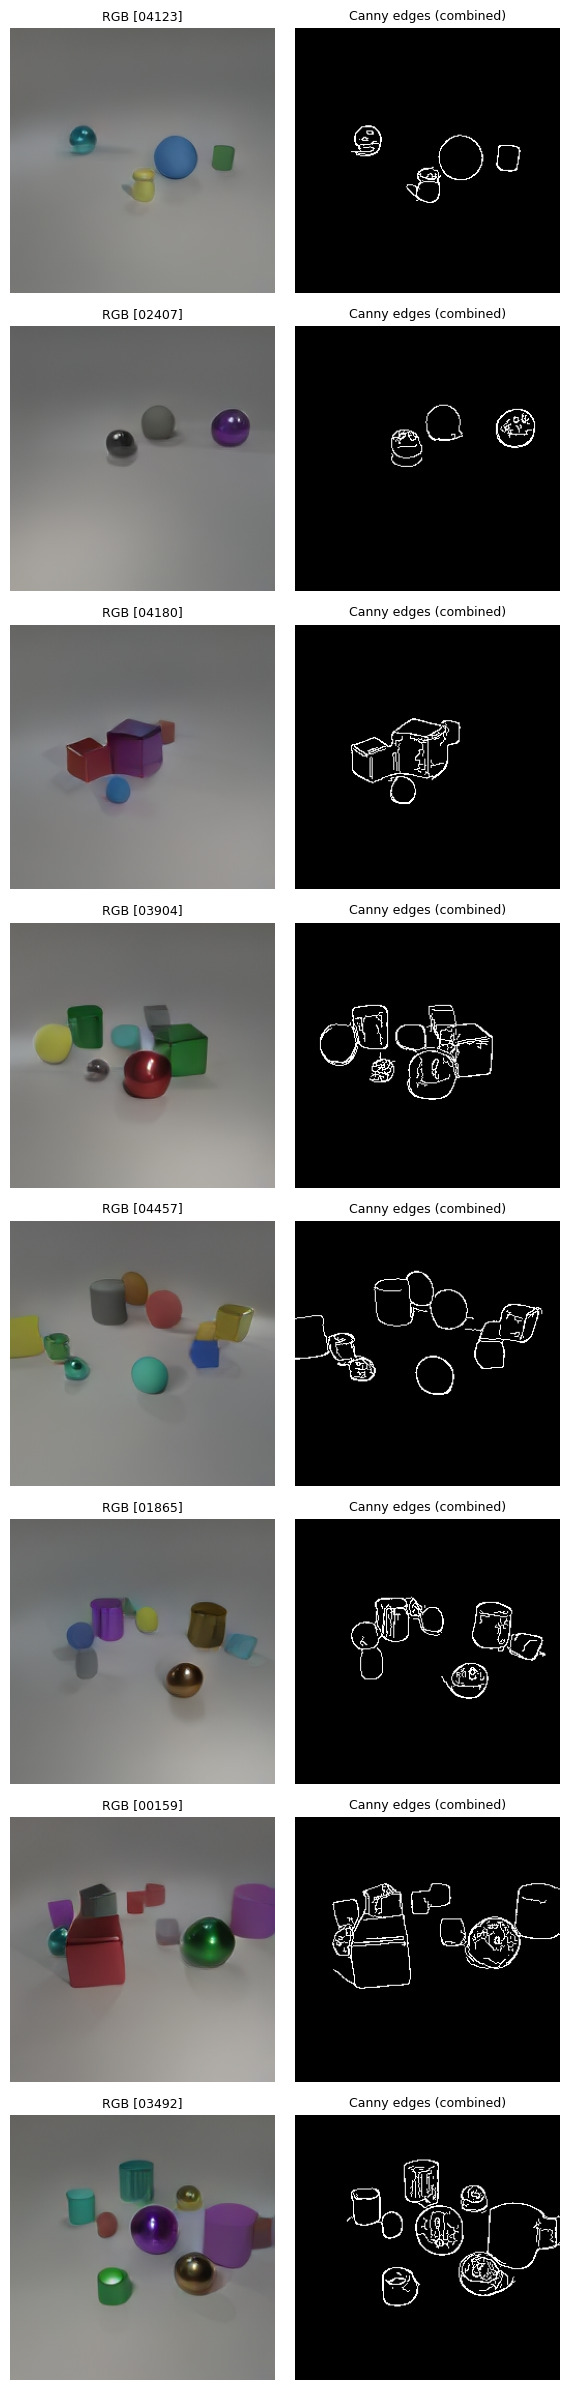

In [13]:
# Visualise 8 random samples — RGB and combined Canny edges
import random

val_rgb_dir = Path('/work/com-304/datasets/clevr_com_304/val/tok_rgb@256')
npy_paths   = sorted(val_rgb_dir.glob('*.npy'))
samples     = random.sample(npy_paths, k=8)

fig, axes = plt.subplots(8, 2, figsize=(6, 24))

for i, p in enumerate(samples):
    rgb_tokens = torch.from_numpy(np.load(p)[0]).long().to(device)
    rgb_img    = token_ids_to_image(rgb_tokens, image_tokenizer)
    rgb_uint8  = (rgb_img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    hsv        = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2HSV)
    sat        = hsv[:, :, 1]
    gray       = (rgb_img.mean(0).numpy() * 255).astype(np.uint8)
    edges_gray = cv2.Canny(cv2.GaussianBlur(gray, (3, 3), 0), 30, 100)
    edges_sat  = cv2.Canny(cv2.GaussianBlur(sat,  (3, 3), 0), 20, 80)
    edges      = cv2.bitwise_or(edges_gray, edges_sat)

    axes[i, 0].imshow(rgb_img.permute(1, 2, 0))
    axes[i, 0].set_title(f'RGB [{p.stem}]', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(edges, cmap='gray')
    axes[i, 1].set_title('Canny edges (combined)', fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### 2.5  Pre-tokenise the full dataset  (NEW)

Run once to save canny edge tokens alongside the existing modalities.
Output layout:
```
/work/com-304/datasets/clevr_com_304/{split}/tok_canny_edge@256/00000.npy
```

---
## 3  Multimodal masked dataset

Five modalities. Note `tok_canny_edge@256` has vocab size **8192**, not 64000.

In [ ]:
modalities   = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'scene_desc', 'tok_canny_edge@256']
vocab_sizes  = [64000,          64000,            64000,            50304,         8192]
max_seq_lens = [256,            256,              256,              256,           256]

In [ ]:
mask_transform = SimpleMultimodalMasking(
    modalities=modalities,
    vocab_sizes=vocab_sizes,
    max_seq_lens=max_seq_lens,
    input_alphas=[1.0, 1.0, 1.0, 1.0, 1.0],
    target_alphas=[1.0, 1.0, 1.0, 1.0, 1.0],
    input_tokens_range=(1, 128),
    target_tokens_range=(1, 128),
    overlap_vocab=True,
    overlap_posembs=True,
    include_unmasked_data_dict=True,
)

In [ ]:
dataset = SimpleMultimodalDataset(
    root_dir='/work/com-304/datasets/clevr_com_304/',
    split='train',
    modalities=modalities,
    sample_from_k_augmentations=10,
    text_tokenizer_path='gpt2',
    text_max_length=256,
    transforms=mask_transform,
)

---
## 4  Dataset visualisation

In [ ]:
def get_modality_with_mask(data_dict, mod_name, mask_type=None):
    tokens = data_dict['unmasked_data_dict'][mod_name].clone()
    L      = tokens.shape[0]
    if mask_type == 'input':
        modality_mask    = data_dict['enc_modalities'] == modalities.index(mod_name)
        modality_mask    = modality_mask & data_dict['enc_pad_mask']
        modality_indices = data_dict['enc_positions'][modality_mask]
    elif mask_type == 'target':
        modality_mask    = data_dict['dec_modalities'] == modalities.index(mod_name)
        modality_mask    = modality_mask & data_dict['dec_pad_mask']
        modality_indices = data_dict['dec_positions'][modality_mask]
    elif mask_type is None:
        modality_indices = torch.arange(L)
    else:
        raise ValueError(f'Unknown mask_type: {mask_type}')
    mask = torch.zeros(L, dtype=torch.bool)
    mask[modality_indices] = True
    return tokens, mask


def get_masked_image(img, mask):
    mask          = mask.reshape(1, 1, 16, 16).float()
    mask          = F.interpolate(mask, (256, 256), mode='nearest')[0, 0].bool()
    img[:, ~mask] = 0
    return img.permute(1, 2, 0)


def plot_data_dict_with_mask(data_dict, mask_type=None):
    # Scene description
    tokens, mask  = get_modality_with_mask(data_dict, 'scene_desc', mask_type=mask_type)
    n_scene_desc  = mask.sum().item()
    tokens[~mask] = 62
    print(f'Scene description: {dataset.text_tokenizer.decode(tokens)}\n')

    fig  = plt.figure(figsize=(16, 4))
    grid = ImageGrid(fig, 111, nrows_ncols=(1, 4), axes_pad=0.1)

    # RGB
    tokens, mask = get_modality_with_mask(data_dict, 'tok_rgb@256', mask_type=mask_type)
    n_rgb = mask.sum().item()
    img   = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[0].imshow(img);  grid[0].set_title('RGB')

    # Depth
    tokens, mask = get_modality_with_mask(data_dict, 'tok_depth@256', mask_type=mask_type)
    n_depth = mask.sum().item()
    img     = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[1].imshow(img);  grid[1].set_title('Depth')

    # Normals
    tokens, mask = get_modality_with_mask(data_dict, 'tok_normal@256', mask_type=mask_type)
    n_normal = mask.sum().item()
    img      = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[2].imshow(img);  grid[2].set_title('Normals')

    # NEW: Canny edges
    tokens, mask = get_modality_with_mask(data_dict, 'tok_canny_edge@256', mask_type=mask_type)
    n_canny  = mask.sum().item()
    img_edge = canny_tokens_to_image(tokens)                           # (1, H, W)
    mask_up  = mask.reshape(1, 1, 16, 16).float()
    mask_up  = F.interpolate(mask_up, (256, 256), mode='nearest')[0, 0].bool()
    img_edge[0, ~mask_up] = 0
    grid[3].imshow(img_edge[0], cmap='gray');  grid[3].set_title('Canny edges')

    plt.show()

    if mask_type is not None:
        print(f'Num. scene_desc tokens:        {n_scene_desc}')
        print(f'Num. tok_rgb@256 tokens:        {n_rgb}')
        print(f'Num. tok_depth@256 tokens:      {n_depth}')
        print(f'Num. tok_normal@256 tokens:     {n_normal}')
        print(f'Num. tok_canny_edge@256 tokens: {n_canny}')
        print('-' * 42)
        print(f'Total tokens: {n_scene_desc + n_rgb + n_depth + n_normal + n_canny}')

In [ ]:
data_dict = dataset[0]

print('########## Original non-masked data ##########')
plot_data_dict_with_mask(data_dict, mask_type=None)

print('\n########## Encoder input ##########')
plot_data_dict_with_mask(data_dict, mask_type='input')

print('\n########## Decoder target ##########')
plot_data_dict_with_mask(data_dict, mask_type='target')

In [ ]:
print('enc_tokens shape:   ', data_dict['enc_tokens'].shape)
print('enc_positions shape:', data_dict['enc_positions'].shape)
print('enc_modalities:     ', data_dict['enc_modalities'].unique())
print('dec_tokens shape:   ', data_dict['dec_tokens'].shape)

---
## 5  Model

Core model code:
- `nanofm/modeling/transformer_layers.py` — CrossAttention, DecoderBlock, TransformerDecoderTrunk
- `nanofm/models/fourm.py` — FourM encoder-decoder Transformer

No architecture changes needed. Only update the training config in `cfgs/`
with the new modality list and vocab size (8192 for canny edges).

### 5.1  Training

```bash
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py \
    --config cfgs/nano4M/multiclevr_d6-6w512_canny.yaml
```

---
## 6  Inference

### 6.1  Load the trained model

In [ ]:
ckpt_path = './outputs/nano4M/multiclevr_d6-6w512_canny/checkpoint-final.safetensors'
model     = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 1e6:.2f}M parameters')

In [ ]:
val_dataset = SimpleMultimodalDataset(
    root_dir='/work/com-304/datasets/clevr_com_304/',
    split='val',
    modalities=modalities,
    sample_from_k_augmentations=1,
    text_tokenizer_path='gpt2',
    text_max_length=256,
    transforms=None,
)

def construct_input_from_sample(dataset, idx, input_modality):
    input_tensor   = dataset[idx][input_modality]
    n_tokens       = input_tensor.shape[0]
    enc_tokens     = input_tensor.unsqueeze(0).to(device)
    enc_positions  = torch.arange(n_tokens, device=device).unsqueeze(0)
    enc_modalities = modalities.index(input_modality) * torch.ones(
                         1, n_tokens, device=device, dtype=torch.long)
    return enc_tokens, enc_positions, enc_modalities


def show_modality(tokens, modality):
    if modality == 'scene_desc':
        print(val_dataset.text_tokenizer.decode(tokens[0]))
    elif modality == 'tok_canny_edge@256':   # NEW
        canny_tokens_to_image(tokens[0], to_pil=True).show()
    else:
        token_ids_to_image(tokens, image_tokenizer, to_pil=True).show()

### 6.2  Generation chains

#### RGB -> Depth -> Normals -> Canny edges -> Scene description

In [ ]:
sample_idx = 4
num_steps, temp, top_p, top_k = 64, 0.7, 0.9, 0.0

x_tokens, x_positions, x_modalities = construct_input_from_sample(
    val_dataset, sample_idx, 'tok_rgb@256'
)
show_modality(x_tokens, 'tok_rgb@256')

In [ ]:
target_mod = 'tok_depth@256'
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

In [ ]:
target_mod = 'tok_normal@256'
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

In [ ]:
# NEW: generate Canny edges
target_mod = 'tok_canny_edge@256'
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

In [ ]:
target_mod = 'scene_desc'
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

#### Canny edges -> RGB  (NEW direction)

In [ ]:
# NEW
sample_idx = 4
x_tokens, x_positions, x_modalities = construct_input_from_sample(
    val_dataset, sample_idx, 'tok_canny_edge@256'
)
show_modality(x_tokens, 'tok_canny_edge@256')

target_mod = 'tok_rgb@256'
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

---
## 7  Further reading

- [4M: Massively Multimodal Masked Modeling](https://4m.epfl.ch/)
- [4M-21: An Any-to-Any Vision Model for Tens of Tasks and Modalities](https://arxiv.org/abs/2406.09406)
- [MultiMAE: Multi-modal Multi-task Masked Autoencoders](https://multimae.epfl.ch/)
- [Cosmos Tokenizer](https://github.com/NVIDIA/Cosmos-Tokenizer)
- [ml-4m (Apple, open-source)](https://github.com/apple/ml-4m)
- [UniDisc: Unified Multimodal Discrete Diffusion](https://unidisc.github.io/)